In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.ticker import MultipleLocator
import matplotlib.dates as mdates

In [12]:
oni = pd.read_csv("nino34_mean.csv",index_col=0,date_parser=lambda x: pd.to_datetime(x,format='%Y-%m-%d'),header=None).iloc[10:-1,0]
oni_pd = oni
oni = oni.to_numpy().flatten()
oni.shape
oni_pd.shape


C:\Users\34723\AppData\Local\Temp\ipykernel_32972\2566432131.py:1: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  oni = pd.read_csv("nino34_mean.csv",index_col=0,date_parser=lambda x: pd.to_datetime(x,format='%Y-%m-%d'),header=None).iloc[10:-1,0]


(145,)

In [17]:
gmst = pd.read_csv("./data/gmst.csv",header=None,index_col=0)
gmst = gmst["1870":"2025"]
gmst_index = gmst.index
oni_pd.index = gmst.index
gmst = gmst.iloc[:,0].to_numpy().flatten()
gmst.shape

(145,)

## 拟合 $ y = ax+b $

In [4]:
coff_x = np.polyfit(oni,gmst,1)

### 再对gmst拟合

In [5]:
coff_gmst  = np.polyfit(np.arange(len(gmst)),gmst,1)

In [6]:
gmst_hat = np.poly1d(coff_x)
gmst_hat_self = np.poly1d(coff_gmst)
gmst_self_ll = gmst_hat_self(np.arange(len(gmst)))
gmst_pre = gmst_hat(oni_pd)
gmst_pre = gmst_pre.flatten()
gmst_self = gmst - gmst_self_ll
gmst_pre.shape

(145,)

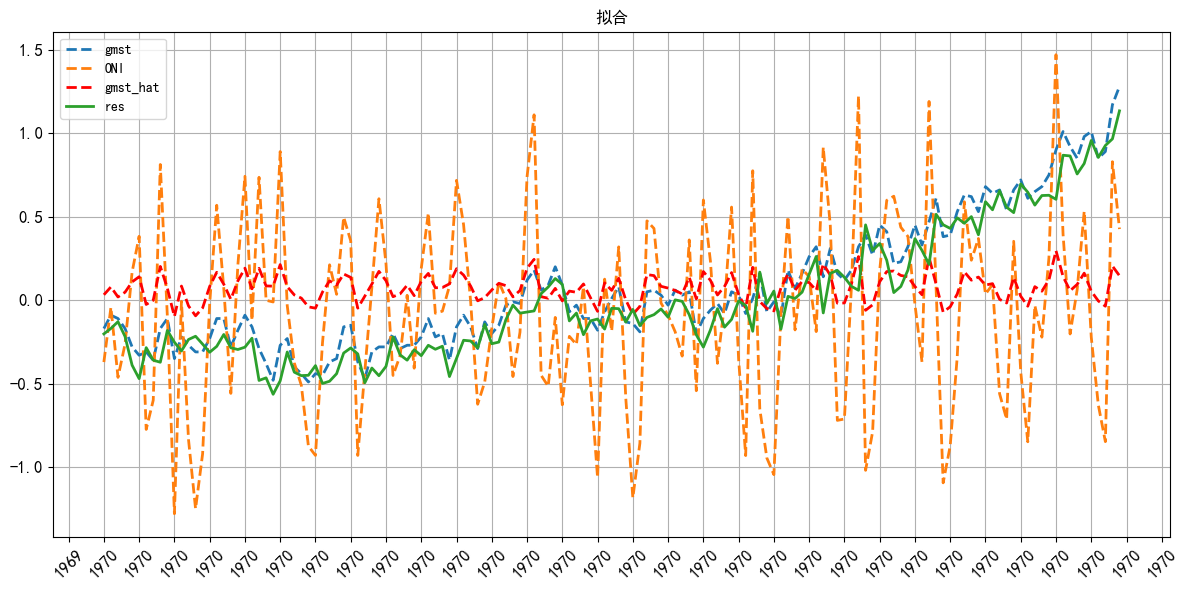

In [8]:
plt.rcParams['font.sans-serif'] = ['SimHei'] 
plt.rcParams['axes.unicode_minus'] = False
fig,ax = plt.subplots(1,1,figsize=(12
                    ,6))
ax.plot(oni_pd.index,gmst, "--",lw = 2.0,label = 'gmst')
ax.plot(oni_pd.index,oni_pd, "--",lw = 2.0,label = 'ONI')
ax.plot(oni_pd.index,gmst_pre,'r--',lw = 2.0,label = 'gmst_hat')
res= gmst-gmst_pre
ax.plot(oni_pd.index,res,'-',lw = 2.0,label = 'res')
#ax.plot(oni_pd.index,gmst_self,'-',lw = 2.0,label = 'gmst_self')
ax.legend(loc = "best")
ax.tick_params(axis='both', which='major', labelsize=12)
ax.xaxis.set_major_locator(MultipleLocator(5))
ax.tick_params(axis='x', rotation=45)
ax.set_title("拟合")
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.grid()
plt.show()

## 相关系数

In [9]:

y_cor= np.corrcoef(oni[:-1],gmst_self[1:])

In [10]:
y_cor

array([[1.        , 0.43568211],
       [0.43568211, 1.        ]])

## 计算 $\hat{y}-y$

In [9]:
res = gmst[:] - gmst_hat(oni)[:]

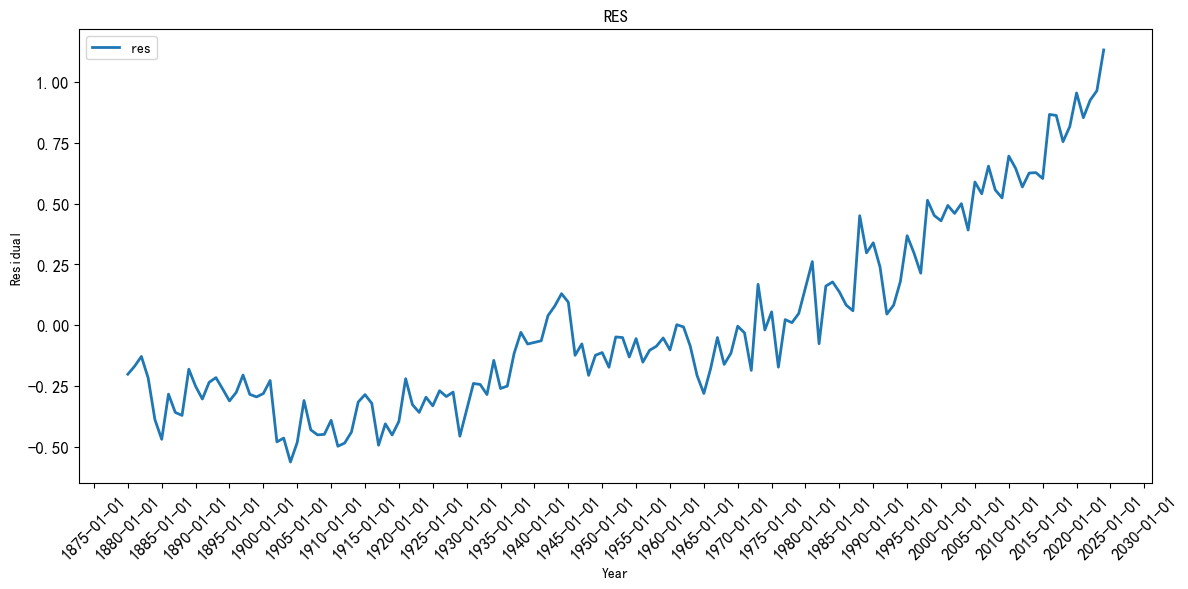

In [33]:
plt.rcParams['font.sans-serif'] = ['SimHei'] 
plt.rcParams['axes.unicode_minus'] = False
fig,ax = plt.subplots(1,1,figsize=(12
                    ,6))
# ax.plot(oni_pd.index,gmst, "--",lw = 2.0,label = 'gmst')
# ax.plot(oni_pd.index,oni_pd, "--",lw = 2.0,label = 'ONI')
# ax.plot(oni_pd.index,gmst_pre,'r--',lw = 2.0,label = 'gmst_hat')
#res= gmst-gmst_pre
ax.plot(gmst_index,res,'-',lw = 2.0,label = 'res')
ax.legend(loc = "best")
ax.tick_params(axis='both', which='major', labelsize=12)
ax.tick_params(axis='x', rotation=45)
ax.set_xlabel("Year")
ax.set_ylabel("Residual")
ax.set_title("RES")
# 设置x轴为时间序列时每隔5年显示一次
import matplotlib.dates as mdates
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.tight_layout()
plt.show()

In [32]:
gmst_index = pd.date_range(start='1880-01-01', end='2024-01-01', freq='YS')

In [36]:
gmst_bynoi = pd.DataFrame(res,index=gmst_index,columns=['res'])
gmst_bynoi.to_csv('./data/gmst_bynoi.csv', header=False)